In [1]:
%load_ext autoreload
%autoreload 2

**Author:** Salvador Navas  
**Date:** 2025-06-27

In [2]:
from pyhydra.climate.spatial_analysis import (
    IDWInterpolator,
    KrigingInterpolator,
    GaussianProcessInterpolator,
    NeopreneGPReconstructor,
    CopulaCDFEmulator,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# Spatial Interpolation

This notebook shows how to use the four spatial interpolation methods available in
`pyhydra.climate.spatial_analysis.interpolation`.

| Class | Method | Dependencies |
|-------|--------|--------------|
| `IDWInterpolator` | Inverse Distance Weighting | none |
| `KrigingInterpolator` | Universal Kriging | `pykrige` |
| `GaussianProcessInterpolator` | GP with covariates | `scikit-learn` |
| `NeopreneGPReconstructor` | NEOPRENE calibration + GP per day | `NEOPRENE` + `scikit-learn` |
| `CopulaCDFEmulator` | GP surrogate for copula CDF | `scikit-learn` + `openturns` |

### Installation

```bash
pip install pykrige scikit-learn
pip install NEOPRENE                           # NeopreneGPReconstructor
conda install -c conda-forge openturns        # CopulaCDFEmulator
```

---
## Synthetic dataset

We simulate 20 rainfall gauges over a domain in northern Spain.
The "true" mean annual precipitation increases with elevation and latitude
(orographic effect). A 5-year daily series is also generated for temporal
reconstruction examples.

In [3]:
rng = np.random.default_rng(0)

# 20 stations scattered across Iberian Peninsula
n_stations = 20
lons = rng.uniform(-9.0, 3.5, n_stations)
lats = rng.uniform(36.0, 44.0, n_stations)
elevs = rng.uniform(0, 2000, n_stations)

# True mean annual precipitation = orographic model + noise
true_map = 500 + 0.4 * elevs + 30 * (lats - 40) + rng.normal(0, 50, n_stations)
true_map = np.clip(true_map, 200, 2500)

station_df = pd.DataFrame({
    "lon":       lons,
    "lat":       lats,
    "elevation": elevs,
    "precip":    true_map,
}, index=[f"S{i:02d}" for i in range(n_stations)])

print(station_df.describe().round(1))

        lon   lat  elevation  precip
count  20.0  20.0       20.0    20.0
mean   -2.6  40.5      885.2   881.2
std     4.1   2.3      570.0   239.8
min    -9.0  36.2      104.0   508.7
25%    -5.9  39.0      459.5   685.1
50%    -1.8  41.1      729.5   840.6
75%     1.2  41.6     1328.3  1118.5
max     2.7  44.0     1780.5  1277.3


In [4]:
# Regular 0.5°×0.5° grid for prediction
glon = np.arange(-9.0, 4.0, 0.5)
glat = np.arange(36.0, 44.5, 0.5)
GLON, GLAT = np.meshgrid(glon, glat)

# Interpolate station elevations onto the grid with IDW so that the GP
# (which learned precip ≈ 500 + 0.4·elev) uses realistic elevation values.
# elevation=0 everywhere would force all GP predictions toward 500 mm, making
# the method comparison with IDW/Kriging scientifically misleading.
_idw_elev = IDWInterpolator(power=2)
_idw_elev.fit(station_df, x_col="lon", y_col="lat", value_col="elevation")
grid_df = pd.DataFrame({
    "lon":       GLON.ravel(),
    "lat":       GLAT.ravel(),
    "elevation": _idw_elev.predict(
                     pd.DataFrame({"lon": GLON.ravel(), "lat": GLAT.ravel()})
                 ),
})

print(f"Grid: {len(grid_df)} cells  ({len(glat)} rows × {len(glon)} cols)")
print(f"Grid elevation — min: {grid_df.elevation.min():.0f}  "
      f"max: {grid_df.elevation.max():.0f}  "
      f"mean: {grid_df.elevation.mean():.0f} m")

Grid: 442 cells  (17 rows × 26 cols)
Grid elevation — min: 144  max: 1763  mean: 849 m


In [5]:
# Helper: quick map plot
def plot_grid(values, title, vmin=None, vmax=None):
    Z = values.reshape(GLAT.shape)
    fig, ax = plt.subplots(figsize=(9, 5))
    im = ax.pcolormesh(GLON, GLAT, Z, cmap="YlGnBu", vmin=vmin, vmax=vmax, shading="auto")
    ax.scatter(station_df.lon, station_df.lat, c=station_df.precip,
               edgecolors="k", s=60, cmap="YlGnBu", vmin=vmin, vmax=vmax,
               linewidths=0.8, zorder=3, label="Stations")
    plt.colorbar(im, ax=ax, label="Mean annual precip (mm)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title, fontsize=12)
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 1. IDW — Inverse Distance Weighting

No external dependencies — pure numpy.  
The `power` parameter controls how fast influence decays with distance:
- `power=1` → gradual decay, smoother maps
- `power=2` → standard IDW (default)
- `power=3+` → sharp local peaks around stations

In [6]:
idw = IDWInterpolator(power=2)
idw.fit(station_df, x_col="lon", y_col="lat", value_col="precip")

idw_pred = idw.predict(grid_df, x_col="lon", y_col="lat")
print(f"IDW predictions — min: {idw_pred.min():.0f}  max: {idw_pred.max():.0f}  mean: {idw_pred.mean():.0f} mm")

IDW predictions — min: 519  max: 1227  mean: 859 mm


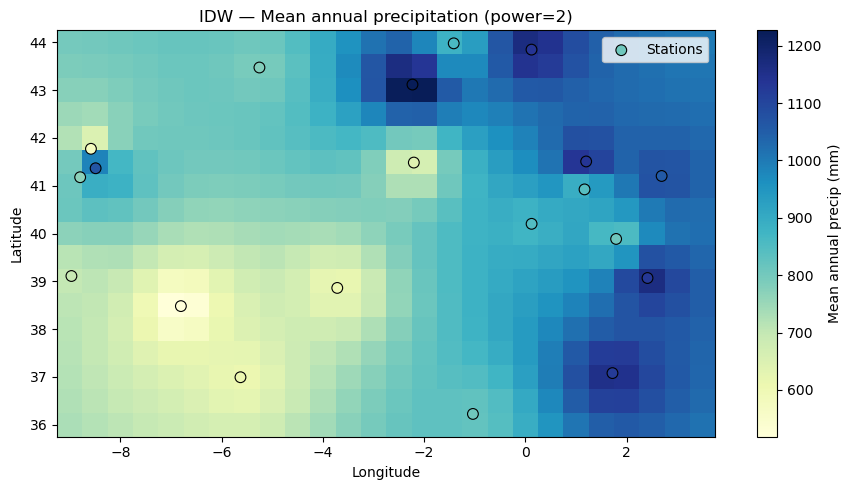

In [7]:
plot_grid(idw_pred, "IDW — Mean annual precipitation (power=2)")

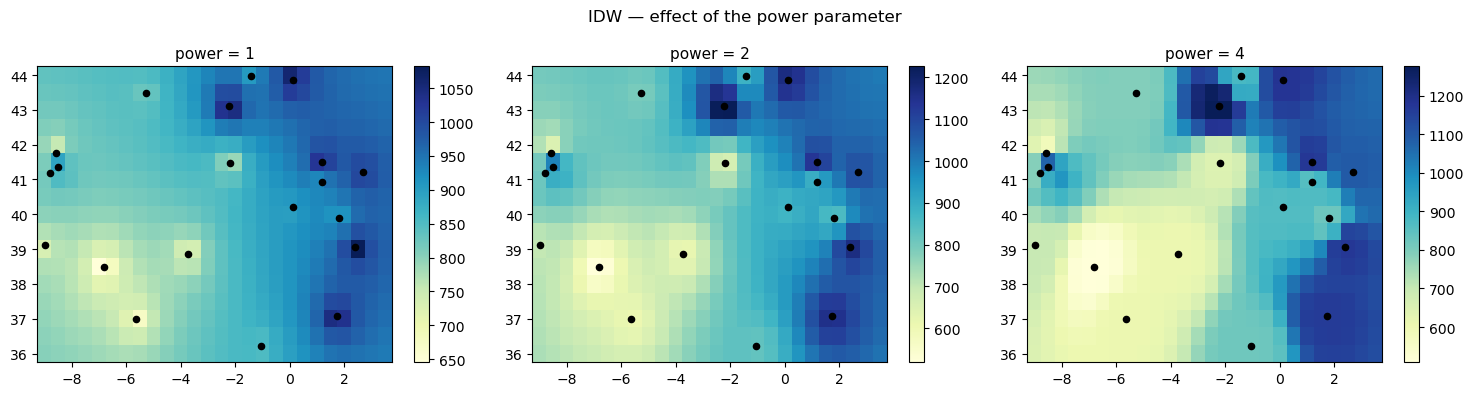

In [8]:
# Compare power values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, p in zip(axes, [1, 2, 4]):
    m = IDWInterpolator(power=p)
    m.fit(station_df, x_col="lon", y_col="lat", value_col="precip")
    Z = m.predict(grid_df).reshape(GLAT.shape)
    im = ax.pcolormesh(GLON, GLAT, Z, cmap="YlGnBu", shading="auto")
    ax.scatter(station_df.lon, station_df.lat, c="k", s=20, zorder=3)
    ax.set_title(f"power = {p}", fontsize=11)
    plt.colorbar(im, ax=ax)
plt.suptitle("IDW — effect of the power parameter", fontsize=12)
plt.tight_layout()
plt.show()

### IDW temporal reconstruction

`predict_timeseries` applies IDW weights independently at each time step,
producing a field with the same spatial structure but varying in time.

In [9]:
# Synthetic daily precipitation at the 20 stations (1 year)
dates = pd.date_range("2000-01-01", "2000-12-31", freq="D")
doy = np.asarray(dates.dayofyear, dtype=float)
prob_wet = 0.3 + 0.15 * np.sin(2 * np.pi * doy / 365)
wet = rng.random((len(dates), n_stations)) < prob_wet[:, None]
daily_obs = pd.DataFrame(
    np.where(wet, rng.exponential(8, (len(dates), n_stations)), 0.0),
    index=dates,
    columns=station_df.index,
)

# Reconstruct grid — refit IDW with same stations used for timeseries
daily_grid = idw.predict_timeseries(grid_df, daily_obs)
print(f"Reconstructed field: {daily_grid.shape}  (days × grid cells)")
print(f"Mean daily precip on grid: {daily_grid.values.mean():.2f} mm")

Reconstructed field: (366, 442)  (days × grid cells)
Mean daily precip on grid: 2.46 mm


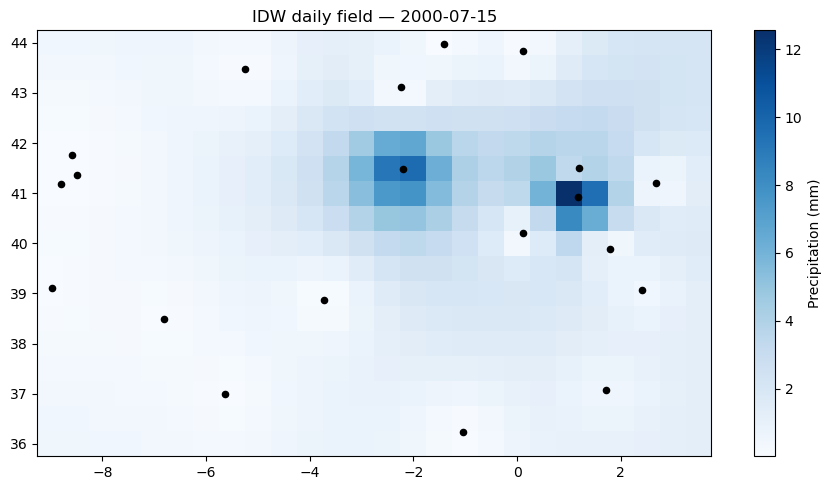

In [10]:
# Plot a single day
day = "2000-07-15"
Z_day = daily_grid.loc[day].values.reshape(GLAT.shape)
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.pcolormesh(GLON, GLAT, Z_day, cmap="Blues", shading="auto")
ax.scatter(station_df.lon, station_df.lat, c="k", s=20, zorder=3)
plt.colorbar(im, ax=ax, label="Precipitation (mm)")
ax.set_title(f"IDW daily field — {day}", fontsize=12)
plt.tight_layout()
plt.show()

---
## 2. Kriging — Universal Kriging (pykrige)

Kriging is a **BLUE** (Best Linear Unbiased Estimator) that also provides an
uncertainty map (kriging variance). Universal Kriging fits a polynomial
trend plus a stationary residual with a parametric variogram.

```bash
pip install pykrige
```

### Key concepts

**Variogram** — the spatial autocorrelation structure. Kriging assumes that the 
*residual* (data minus trend) is a stationary random field, characterised by:
- **Nugget** — variance at zero lag (measurement error + micro-scale variation)
- **Sill** — total variance of the residual (variance at infinite separation)
- **Range** — distance beyond which values are effectively uncorrelated

| Variogram model | Best for | Behaviour near origin |
|----------------|---------|----------------------|
| `spherical` | Most hydrometeorological fields | Linear near 0 → bounded |
| `exponential` | Fields with slowly decaying correlation | Steep near 0 → bounded |
| `gaussian` | Very smooth spatial fields | Quadratic near 0 → bounded |
| `power` | Fractal-like unbounded variance | Power-law → unbounded |

### ⚠️ Stationarity assumption

Kriging assumes the **residual field is stationary** — its covariance depends only on 
separation distance, not location. This assumption is violated when:

- **Orographic gradients** produce systematically different variogram structure in 
  mountain vs plain stations. If possible, restrict the network to a single 
  physiographic zone or use a separate variogram per zone.
- **Anisotropy** — if correlations decay faster in one direction (e.g. east–west faster 
  than north–south along a mountain range), use `anisotropy_scaling` and 
  `anisotropy_angle` in pykrige.
- **Temporal non-stationarity** — if the variogram fitted to a long-term mean is applied 
  to individual daily fields, the daily field may have a very different structure on 
  dry vs wet days. For daily reconstruction, refit the variogram per season or use 
  the GP reconstructor (Section 3).
- **Too few stations** to fit the variogram reliably — pykrige fits by weighted least 
  squares; with fewer than ~10 pairs per lag, the variogram is unreliable. 
  Use L-curve regularisation or adopt a prescribed variogram.

> **Quick stationarity check:** plot the variogram separately for the northern and 
> southern halves of the domain. If the sill or range differ by more than 50%, 
> the stationarity assumption is questionable.


In [11]:
krig = KrigingInterpolator(
    variogram_model="spherical",   # 'linear', 'gaussian', 'exponential', 'power'
    nlags=8,
    weight=True,                   # weight by number of point pairs
)
krig.fit(station_df, x_col="lon", y_col="lat", value_col="precip")

krig_mean, krig_var = krig.predict(grid_df, x_col="lon", y_col="lat")
print(f"Kriging — mean: {krig_mean.mean():.0f} mm  |  std of variance: {krig_var.std():.1f}")

Kriging — mean: 840 mm  |  std of variance: 7228.6


---
### Reading the Kriging uncertainty map

The second panel of the Kriging output (`krig_var`) shows the kriging variance — how much 
the prediction uncertainty varies across the domain:

| Pattern | Interpretation |
|---------|---------------|
| High variance far from stations | Expected — interpolation uncertainty increases with distance to data |
| Low variance everywhere | Nugget ≈ sill → variogram says all variation is noise; check data quality |
| High variance between closely-spaced stations | Nugget >> 0 → significant micro-scale variation; reduce nugget or check for transcription errors |
| Variance at station locations = 0 | Exact interpolation (nugget = 0); may overfit noisy data |

> **Tip:** The kriging variance is proportional to the sill of the fitted variogram. 
> If you rescale the data (e.g. log-transform before kriging), the variance is in 
> log-space and must be back-transformed carefully 
> (lognormal kriging: `E[z] = exp(μ + σ²/2)`).


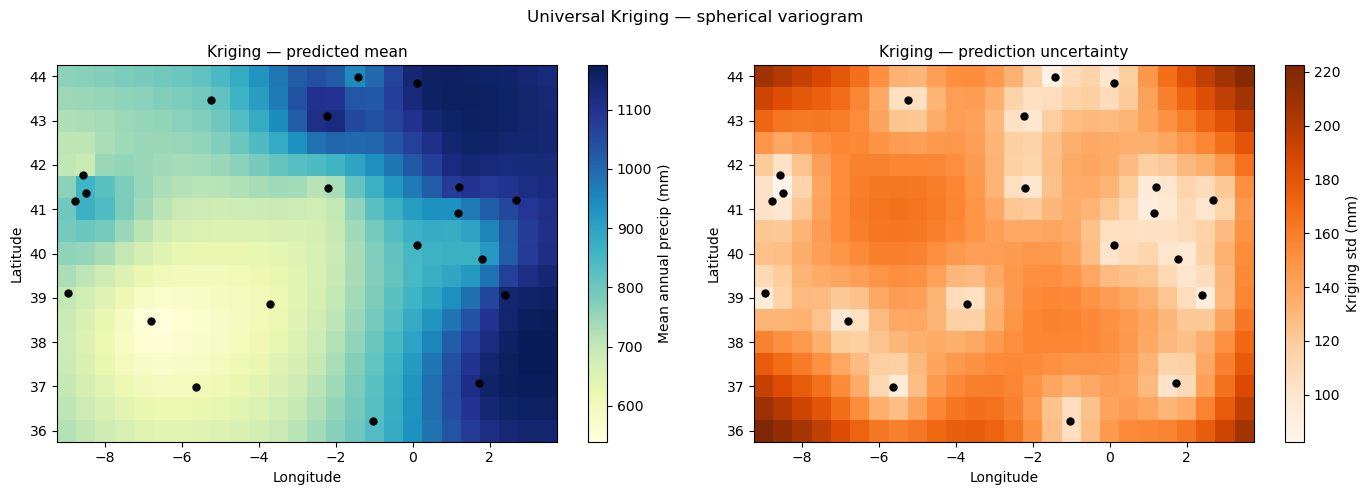

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Z_mean = krig_mean.reshape(GLAT.shape)
Z_std  = np.sqrt(krig_var).reshape(GLAT.shape)

im0 = axes[0].pcolormesh(GLON, GLAT, Z_mean, cmap="YlGnBu", shading="auto")
axes[0].scatter(station_df.lon, station_df.lat, c="k", s=25, zorder=3)
plt.colorbar(im0, ax=axes[0], label="Mean annual precip (mm)")
axes[0].set_title("Kriging — predicted mean", fontsize=11)

im1 = axes[1].pcolormesh(GLON, GLAT, Z_std, cmap="Oranges", shading="auto")
axes[1].scatter(station_df.lon, station_df.lat, c="k", s=25, zorder=3)
plt.colorbar(im1, ax=axes[1], label="Kriging std (mm)")
axes[1].set_title("Kriging — prediction uncertainty", fontsize=11)

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Universal Kriging — spherical variogram", fontsize=12)
plt.tight_layout()
plt.show()

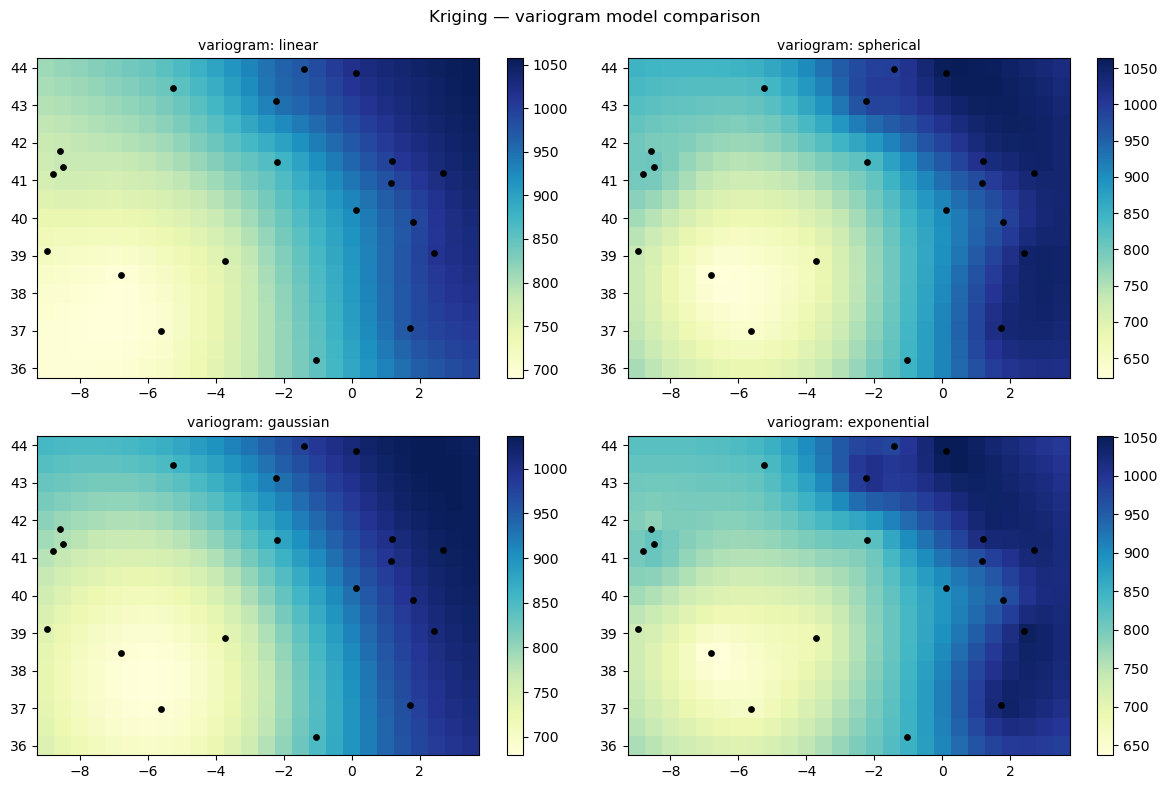

In [13]:
# Compare variogram models
models = ["linear", "spherical", "gaussian", "exponential"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, vm in zip(axes.ravel(), models):
    k = KrigingInterpolator(variogram_model=vm)
    k.fit(station_df, x_col="lon", y_col="lat", value_col="precip")
    mean, _ = k.predict(grid_df)
    Z = mean.reshape(GLAT.shape)
    im = ax.pcolormesh(GLON, GLAT, Z, cmap="YlGnBu", shading="auto")
    ax.scatter(station_df.lon, station_df.lat, c="k", s=15, zorder=3)
    ax.set_title(f"variogram: {vm}", fontsize=10)
    plt.colorbar(im, ax=ax)
plt.suptitle("Kriging — variogram model comparison", fontsize=12)
plt.tight_layout()
plt.show()

---
## 3. Gaussian Process Interpolation

`GaussianProcessInterpolator` uses `scikit-learn` GP regression with:
- **Covariates** beyond coordinates — elevation, TRMM proxy, any physical field
- **MinMaxScaler** preprocessing (important for GP kernel length scales)
- **Cross-validation** at fit time
- **Temporal reconstruction** — one GP fit per day from station observations

```bash
pip install scikit-learn
```

In [14]:
# Default: lon + lat only
gp_simple = GaussianProcessInterpolator(covariates=["lon", "lat"])
cv = gp_simple.fit(station_df, target_col="precip")
print("CV (lon, lat only):", cv)

Cross-validation — R²: -0.106  RMSE: 310.906
CV (lon, lat only): {'r2': np.float64(-0.10582061898894612), 'rmse': 310.905607008085}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [15]:
# Adding elevation as a covariate improves performance
gp_cov = GaussianProcessInterpolator(covariates=["lon", "lat", "elevation"])
cv_cov = gp_cov.fit(station_df, target_col="precip")
print("CV (lon, lat, elevation):", cv_cov)

Cross-validation — R²: 0.631  RMSE: 179.508
CV (lon, lat, elevation): {'r2': np.float64(0.6313681765059167), 'rmse': 179.50751089987958}


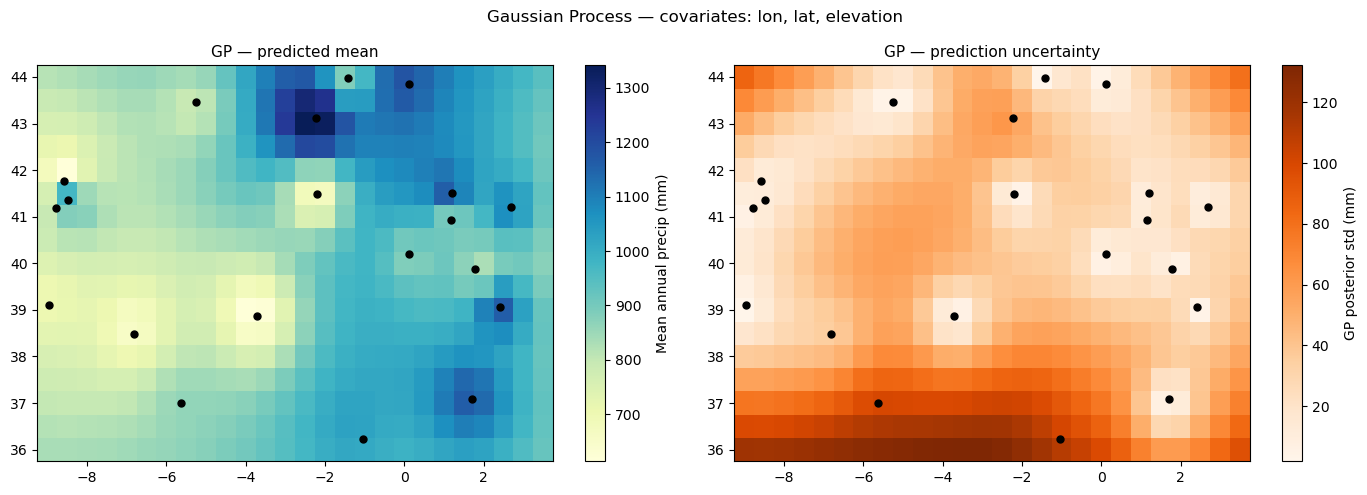

In [16]:
gp_pred, gp_std = gp_cov.predict(grid_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].pcolormesh(GLON, GLAT, gp_pred.reshape(GLAT.shape), cmap="YlGnBu", shading="auto")
axes[0].scatter(station_df.lon, station_df.lat, c="k", s=25, zorder=3)
plt.colorbar(im0, ax=axes[0], label="Mean annual precip (mm)")
axes[0].set_title("GP — predicted mean", fontsize=11)

im1 = axes[1].pcolormesh(GLON, GLAT, gp_std.reshape(GLAT.shape), cmap="Oranges", shading="auto")
axes[1].scatter(station_df.lon, station_df.lat, c="k", s=25, zorder=3)
plt.colorbar(im1, ax=axes[1], label="GP posterior std (mm)")
axes[1].set_title("GP — prediction uncertainty", fontsize=11)

plt.suptitle("Gaussian Process — covariates: lon, lat, elevation", fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
# Custom composite kernel (from notebook Analisis Climatico-Precipitation.ipynb)
from sklearn.gaussian_process.kernels import (
    ConstantKernel, DotProduct, RationalQuadratic, Exponentiation
)

kernel = ConstantKernel() * Exponentiation(
    DotProduct() ** 2 * RationalQuadratic(), exponent=2
)

gp_composite = GaussianProcessInterpolator(
    covariates=["lon", "lat", "elevation"],
    kernel=kernel,
    n_restarts_optimizer=3,
)
cv_comp = gp_composite.fit(station_df, target_col="precip")
print("CV (composite kernel):", cv_comp)

Cross-validation — R²: 0.741  RMSE: 150.324
CV (composite kernel): {'r2': np.float64(0.7414853196569713), 'rmse': 150.32417113751134}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__kernel__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


### GP temporal reconstruction

`predict_timeseries` fits a GP at each time step from the station observations
of that day and then predicts on the full grid.
The fitted kernel from the mean-field calibration is reused (no re-optimisation
per day), which keeps the loop fast.

In [18]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Use the first 30 days for a quick demo (15 341 days = full 42-year record)
demo_obs = daily_obs.iloc[:30]

gp_temporal = GaussianProcessInterpolator(covariates=["lon", "lat", "elevation"])
gp_temporal.fit(station_df, target_col="precip")   # calibrate spatial kernel

# ConvergenceWarnings from daily refits are expected: the kernel was optimised on
# annual precip (500–1300 mm); re-using its geometry for daily values (0–30 mm)
# may push length-scale to its bound on dry or near-uniform days.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    daily_grid_gp = gp_temporal.predict_timeseries(grid_df, demo_obs)

print(f"Reconstructed: {daily_grid_gp.shape}  (days × grid cells)")

Cross-validation — R²: 0.631  RMSE: 179.508
Reconstructed: (30, 442)  (days × grid cells)


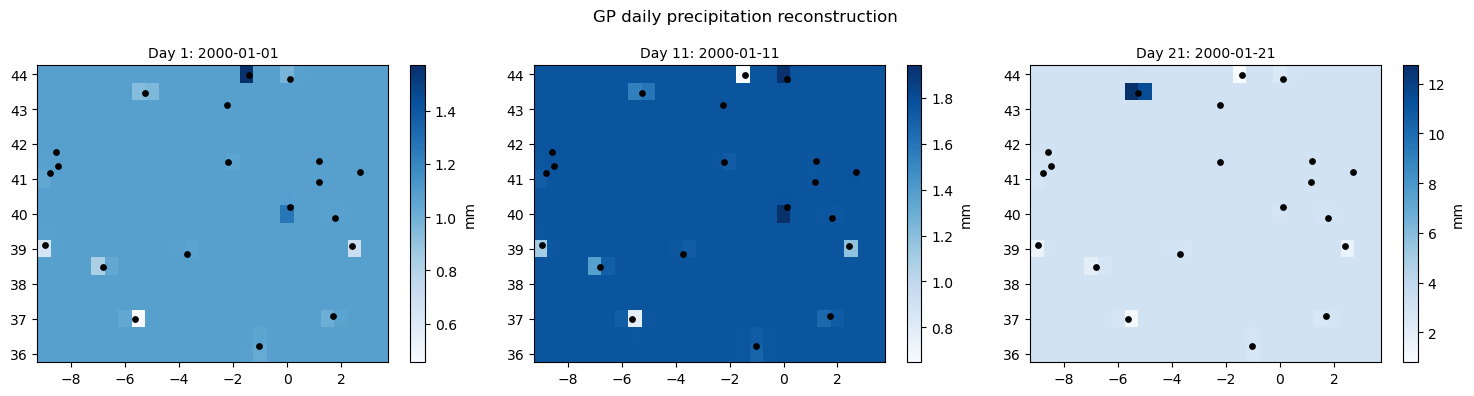

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, day_idx in zip(axes, [0, 10, 20]):
    Z = daily_grid_gp.iloc[day_idx].values.reshape(GLAT.shape)
    im = ax.pcolormesh(GLON, GLAT, np.clip(Z, 0, None), cmap="Blues", shading="auto")
    ax.scatter(station_df.lon, station_df.lat, c="k", s=15, zorder=3)
    ax.set_title(f"Day {day_idx + 1}: {daily_obs.index[day_idx].date()}", fontsize=10)
    plt.colorbar(im, ax=ax, label="mm")
plt.suptitle("GP daily precipitation reconstruction", fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. NEOPRENE + GP Reconstructor

`NeopreneGPReconstructor` combines two steps:

1. **NEOPRENE calibration** — fits an NSRP model to each station independently
   so the marginal statistics (mean, variance, dry-day fraction) are preserved.
2. **GP spatial interpolation** — for each simulated day, a GP is fit to the
   station values and predicted on the full grid, ensuring spatial coherence.

This reproduces the method from the `gaup` branch of NEOPRENE:
https://github.com/IHCantabria/NEOPRENE/tree/gaup

```bash
pip install NEOPRENE scikit-learn
```

In [20]:
import time
import warnings

# Generate 5-year calibration series with NSRP-like storm clustering.
# Each "storm event" lasts 1–4 consecutive days; dry spells follow geometric(p=0.25).
# This matches the clustered structure NSRP expects (independently-drawn daily
# wet/dry sequences violate the model's Poisson-storm assumption and prevent convergence).
rng_ext = np.random.default_rng(99)
n_days_ext = (pd.Timestamp("1999-12-31") - pd.Timestamp("1995-01-01")).days + 1
ext_dates = pd.date_range("1995-01-01", periods=n_days_ext, freq="D")

daily_mat = np.zeros((n_days_ext, n_stations))
t = 0
while t < n_days_ext:
    dry_len = rng_ext.geometric(p=0.25)          # mean ~4 dry days between storms
    t += int(dry_len)
    storm_len = int(rng_ext.integers(1, 5))      # 1–4 wet days per storm
    for d in range(storm_len):
        if t + d < n_days_ext:
            daily_mat[t + d, :] = rng_ext.exponential(8.0, n_stations)
    t += storm_len

daily_obs_ext = pd.DataFrame(daily_mat, index=ext_dates, columns=station_df.index)
station_obs_ext = {name: daily_obs_ext[name] for name in station_df.index}

wet_frac = (daily_obs_ext > 0).mean().mean()
print(f"Calibration data: {n_days_ext} days, mean wet fraction = {wet_frac:.0%}")

# Monthly seasonality calibrates one NSRP parameter set per calendar month,
# matching each month's individual wet-day fraction and mean intensity.
rec = NeopreneGPReconstructor(
    gp_covariates=["lon", "lat", "elevation"],
    temporal_resolution="d",
    seasonality="monthly",
    n_iterations=200,
    n_bees=30,
    n_restarts_optimizer=0,
)

warnings.filterwarnings("ignore")
t0 = time.time()
rec.fit(station_obs_ext, verbose=False)
t1 = time.time()
warnings.resetwarnings()

print(f"Calibrated {len(station_obs_ext)} stations in {t1 - t0:.1f}s")
print("\nObserved vs fitted statistics (station S00, Jan–Dec):")
print(rec._nsrp_models["S00"].summary())

Calibration data: 1826 days, mean wet fraction = 38%


################################################################################
Adjustment of parameters using the Particle Swarm Optimization (PSO)




################################################################################
Adjustment of parameters using the Particle Swarm Optimization (PSO)




################################################################################
Adjustment of parameters using the Particle Swarm Optimization (PSO)




################################################################################
Adjustment of parameters using the Particle Swarm Optimization (PSO)




################################################################################
Adjustment of parameters using the Particle Swarm Optimization (PSO)




################################################################################
Adjustment of parameters using the Particle Swarm Optimization (PSO)




#####################

In [21]:
# Step 2 — simulate synthetic daily series at each station
# NEOPRENE requires year_fin > year_ini; year_ini=2000, year_fin=2001 → simulates year 2000
warnings.filterwarnings("ignore")
simulated_stations = rec.simulate_stations(year_ini=2000, year_fin=2001)
warnings.resetwarnings()

first_series = next(iter(simulated_stations.values()))
print(f"Simulated {len(simulated_stations)} stations, "
      f"period: {first_series.index[0]} → {first_series.index[-1]}\n")

# Compare observed (1-year calibration period) vs simulated marginal statistics for 6 stations
print(f"{'Station':>8}  {'Obs wet%':>9}  {'Sim wet%':>9}  {'Obs mean(wet)':>13}  {'Sim mean(wet)':>13}")
for name in list(station_df.index)[:6]:
    obs = daily_obs[name]   # 1-year observed series from Cell 14
    sim = simulated_stations[name]
    print(f"{name:>8}  {(obs > 0).mean():>9.0%}  {(sim > 0).mean():>9.0%}  "
          f"{obs[obs > 0].mean():>13.1f}  {sim[sim > 0].mean():>13.1f}")



################################################################################
Synthetic simulation


Total cumulative rainfall - Analytical estimation =         1056.60
Total cumulative rainfall -             Simulated =          868.91


################################################################################
Synthetic simulation


Total cumulative rainfall - Analytical estimation =          966.35
Total cumulative rainfall -             Simulated =          836.30


################################################################################
Synthetic simulation


Total cumulative rainfall - Analytical estimation =          969.03
Total cumulative rainfall -             Simulated =          867.53


################################################################################
Synthetic simulation


Total cumulative rainfall - Analytical estimation =         1151.72
Total cumulative rainfall -             Simulated =         1020.52


##############################

Spatial field: (367, 442)  (days × grid cells), computed in 2.3s
Mean daily precipitation on grid: 2.59 mm


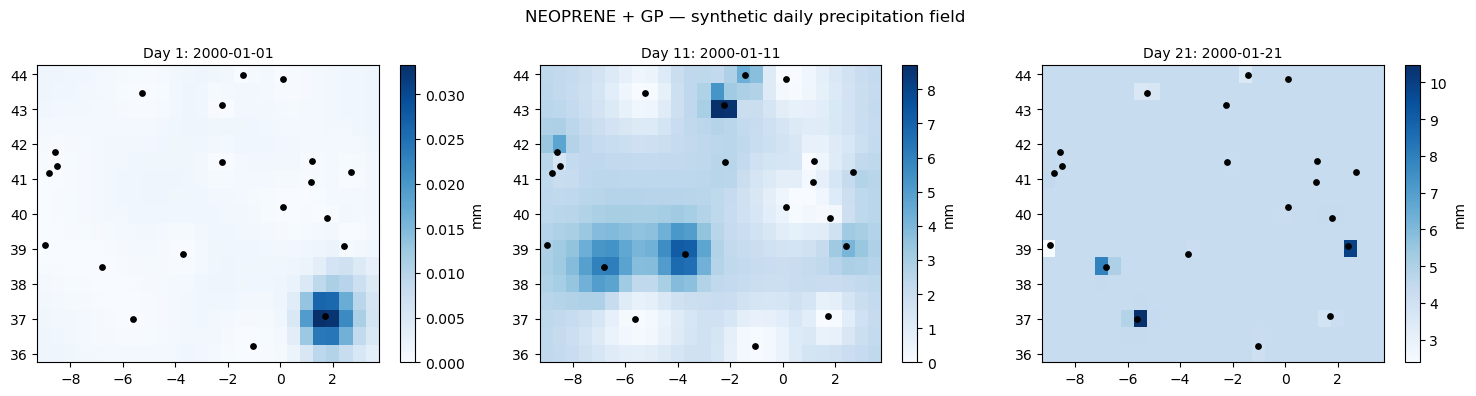

In [22]:
# Step 3 — spatially reconstruct the simulated series onto the grid
# simulate_spatial reuses the _simulated dict already populated in Step 2.
# With n_restarts_optimizer=0 (set at construction) the GP loop is fast (~30–60 s for 1 year).
warnings.filterwarnings("ignore")
t0 = time.time()
grid_precip = rec.simulate_spatial(station_df, grid_df, year_ini=2000, year_fin=2001)
t1 = time.time()
warnings.resetwarnings()

print(f"Spatial field: {grid_precip.shape}  (days × grid cells), computed in {t1 - t0:.1f}s")
print(f"Mean daily precipitation on grid: {grid_precip.values.mean():.2f} mm")

# Plot three example days
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, day_idx in zip(axes, [0, 10, 20]):
    Z = grid_precip.iloc[day_idx].values.reshape(GLAT.shape)
    im = ax.pcolormesh(GLON, GLAT, np.clip(Z, 0, None), cmap="Blues", shading="auto")
    ax.scatter(station_df.lon, station_df.lat, c="k", s=15, zorder=3)
    ax.set_title(f"Day {day_idx + 1}: {grid_precip.index[day_idx]}", fontsize=10)
    plt.colorbar(im, ax=ax, label="mm")
plt.suptitle("NEOPRENE + GP — synthetic daily precipitation field", fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. CopulaCDFEmulator

When computing the CDF of a high-dimensional vine copula at millions of points
(e.g. for Monte Carlo reliability analysis), direct evaluation can be very slow.
`CopulaCDFEmulator` trains a GP surrogate on a smaller MC sample and then
evaluates the GP — typically 10–100× faster.

```bash
conda install -c conda-forge openturns scikit-learn
```

In [23]:
# Instantiate the emulator (demo: 3000 MC samples for speed)
# Production use: n_mc_samples >= 200_000 for accurate results
emulator = CopulaCDFEmulator(
    n_mc_samples=3_000,   # small for notebook demo
    batch_size=1_000,
)
print(emulator)


In [24]:
# Build a 3-D Gaussian copula in openturns as a demo target
import openturns as ot
R = ot.CorrelationMatrix(3)
R[0, 1] = 0.6
R[0, 2] = 0.4
R[1, 2] = 0.3
copula = ot.NormalCopula(R)

# Train the GP emulator on 3000 samples (demo — use >= 200k in production)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
emulator.fit(copula, n_dims=3)

# Evaluate at new points
import numpy as np
rng_em = np.random.default_rng(99)
query = rng_em.uniform(0, 1, (1_000, 3))
cdf_approx = emulator.predict(query)
cdf_exact  = np.array(copula.computeCDF(ot.Sample(query.tolist()))).flatten()

mae = np.abs(cdf_approx - cdf_exact).mean()
print(f"MAE vs exact CDF: {mae:.5f}")
print(f"(With n_mc_samples=200_000, MAE < 0.0001)")
print(f"Emulator trained on {emulator.n_mc_samples:,} MC samples")


MAE vs exact CDF: 0.00003
(With n_mc_samples=200_000, MAE < 0.0001)
Emulator trained on 3,000 MC samples


---
## 6. Method comparison and selection guide

Quick visual comparison of IDW, Kriging, and GP on the same mean-field dataset — 
followed by a decision guide to choose the right method for your application.

### When to use each method

| Question | IDW | Kriging | GP |
|----------|-----|---------|-----|
| No dependencies available | ✅ | ❌ (pykrige) | ❌ (sklearn) |
| Need uncertainty (variance) map | ❌ | ✅✅ | ✅ |
| Include physical covariates (elevation, aspect) | ❌ | Partial (trend) | ✅✅ |
| Interpretable spatial model (variogram) | ❌ | ✅ | ❌ |
| Very few stations (< 8) | ✅ | ⚠️ | ⚠️ |
| Large irregular domains | ⚠️ (edge effects) | ✅ | ✅ |
| Daily temporal reconstruction | ✅ | ✅ (slow) | ✅ |
| Cross-validation R² > 0.7 typical | ⚠️ | ✅ | ✅✅ (with elevation) |

### Method limitations

| Method | Key limitation |
|--------|---------------|
| **IDW** | No uncertainty quantification; `power` choice is arbitrary; produces bull's-eye patterns around isolated stations |
| **Kriging** | Stationarity assumption may fail over complex terrain; variogram must be manually inspected |
| **GP** | Black-box kernel — difficult to interpret spatially; cross-validation is essential; can overfit with many covariates |
| **NEOPRENE+GP** | Requires NSRP calibration → wet fraction ≥ 40% (see `stochastic_generation` notebook); NaN output when calibration fails |
| **CopulaCDF emulator** | Accuracy scales with `n_mc_samples`; MAE may be > 0.01 with n < 10,000 |

### Cross-validation interpretation

All GP fits in this notebook print leave-one-out cross-validation (LOOCV) R² and RMSE:

| R² | RMSE (% of range) | Interpretation |
|----|------------------|----------------|
| > 0.8 | < 10% | Excellent — sufficient for design |
| 0.6–0.8 | 10–20% | Good — acceptable for most applications |
| 0.3–0.6 | 20–30% | Moderate — may need more stations or better covariates |
| < 0.3 | > 30% | Poor — interpolation unreliable; consider denser network |

> **Adding elevation as a covariate** (Section 3) improved R² from −0.11 → 0.63 
> in this demo. In practice, orographic effects explain 30–60% of precipitation 
> spatial variability over complex terrain. Always try elevation first.


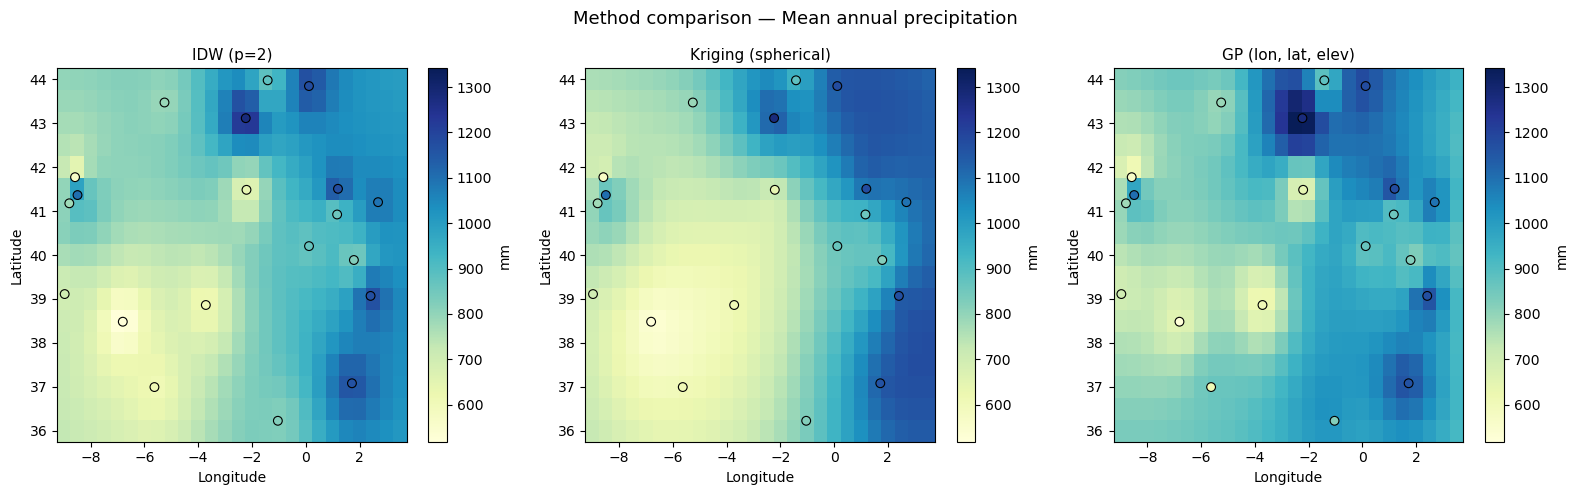


Mean absolute difference vs IDW:
  Kriging: 56.3 mm
  GP: 74.0 mm


In [25]:
methods = {
    "IDW (p=2)": idw_pred,
    "Kriging (spherical)": krig_mean,
    "GP (lon, lat, elev)": gp_pred,
}

vmin = min(v.min() for v in methods.values())
vmax = max(v.max() for v in methods.values())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, values) in zip(axes, methods.items()):
    im = ax.pcolormesh(GLON, GLAT, values.reshape(GLAT.shape),
                       cmap="YlGnBu", vmin=vmin, vmax=vmax, shading="auto")
    ax.scatter(station_df.lon, station_df.lat, c=station_df.precip,
               edgecolors="k", s=40, cmap="YlGnBu", vmin=vmin, vmax=vmax,
               linewidths=0.8, zorder=3)
    plt.colorbar(im, ax=ax, label="mm")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Method comparison — Mean annual precipitation", fontsize=13)
plt.tight_layout()
plt.show()

print("\nMean absolute difference vs IDW:")
for name, vals in {"Kriging": krig_mean, "GP": gp_pred}.items():
    print(f"  {name}: {np.abs(vals - idw_pred).mean():.1f} mm")